# Exploratory Data Analysis

Perform EDA covering:
- Data Summarization - descriptive statistics for numerical features (TotalPremium, TotalClaims, etc.), and a review of dtypes to confirm categorical, date, and numerical columns are correctly typed.
- Data Quality Assessment - check for missing values and document handling strategy.
- Univariate Analysis - histograms for numerical columns and bar charts for categorical columns.
- Bivariate / Multivariate Analysis - relationships between TotalPremium and TotalClaims as a function of ZipCode, using scatter plots and correlation matrices.
- Geographic Trends - compare cover type, premium, and auto make across provinces.
- Outlier Detection - use box plots on key numerical features.

In [2]:
import sys
from pathlib import Path
# Ensure project root is on sys.path so `import src` works when notebook is run from `notebooks/`
proj_root = Path.cwd().resolve().parent
proj_root_str = str(proj_root)
if proj_root_str not in sys.path:
    sys.path.insert(0, proj_root_str)
print('Added to sys.path:', proj_root_str)

Added to sys.path: C:\Users\teMelkishi\Desktop\projects\tenx\projects\insurance-risk-analytics


In [3]:
from src.data_loader import (
    load_insurance_data, 
    load_cleaned_data,
)
from src.eda_utils import (
    summarize_data, 
    check_data_quality, 
    plot_numerical_distributions,
    plot_categorical_distributions, 
    plot_premium_vs_claims, 
    plot_correlation_matrix, 
    analyze_geographic_trends, 
    analyze_vehicle_makes, 
    save_cleaned_data,
    detect_outliers, 
    create_derived_metrics, 
    handle_missing_values,
    get_numerical_columns,
    get_categorical_columns,
    check_missing_values,
    cast_column_types,
    verify_column_types,
    recalculate_loss_ratio,
    remove_duplicate_rows,
)

In [4]:
# Load the data
df = load_insurance_data(file_path="../data/insurance_data.txt")
df.head()

INFO:src.data_loader:Loading data from: ../data/insurance_data.txt
INFO:src.data_loader:✅ Data loaded successfully! Shape: (1000098, 52)
INFO:src.data_loader:Columns: ['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode', 'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors', 'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet', 'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm', 'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium', 'TotalClaims']


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


### Data Summarization

In [5]:
summarize_data(df)

DATA SUMMARIZATION
Dataset Shape: 1,000,098 rows × 52 columns

DATA TYPES:
str        36
float64    11
int64       4
bool        1
Name: count, dtype: int64


NUMERICAL COLUMNS (15):
['UnderwrittenCoverID', 'PolicyID', 'PostalCode', 'mmcode', 'RegistrationYear', 'Cylinders', 'cubiccapacity', 'kilowatts', 'NumberOfDoors', 'CustomValueEstimate', 'NumberOfVehiclesInFleet', 'SumInsured', 'CalculatedPremiumPerTerm', 'TotalPremium', 'TotalClaims']

Descriptive Statistics:
       UnderwrittenCoverID    PolicyID  PostalCode       mmcode  \
count           1000098.00  1000098.00  1000098.00    999546.00   
mean             104817.55     7956.68     3020.60  54877704.02   
std               63293.71     5290.04     2649.85  13603805.34   
min                   1.00       14.00        1.00   4041200.00   
25%               55143.00     4500.00      827.00  60056925.00   
50%               94083.00     7071.00     2000.00  60058415.00   
75%              139190.00    11077.00     4180.00  60058418

In [6]:
date_cols = ["TransactionMonth", "RegistrationYear", "VehicleIntroDate"]
categorical_cols = get_categorical_columns(df)
numerical_cols = get_numerical_columns(df)

print("Categorical columns:")
print(categorical_cols)
print("Numerical columns:")
print(numerical_cols)
print("Date columns:")
print(date_cols)

Categorical columns: ['Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'VehicleType', 'make', 'Model', 'bodytype', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'TermFrequency', 'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass', 'StatutoryRiskType']
Numerical columns: ['UnderwrittenCoverID', 'PolicyID', 'PostalCode', 'mmcode', 'RegistrationYear', 'Cylinders', 'cubiccapacity', 'kilowatts', 'NumberOfDoors', 'CustomValueEstimate', 'NumberOfVehiclesInFleet', 'SumInsured', 'CalculatedPremiumPerTerm', 'TotalPremium', 'TotalClaims']
Categorical columns:
['Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'VehicleType', 'make', 'M

In [7]:
df = cast_column_types(df, categorical_cols,  date_cols, numerical_cols)

COLUMN TYPE CASTING
✓ Citizenship                    → category
✓ LegalType                      → category
✓ Title                          → category
✓ Language                       → category
✓ Bank                           → category
✓ AccountType                    → category
✓ MaritalStatus                  → category
✓ Gender                         → category
✓ Country                        → category
✓ Province                       → category
✓ MainCrestaZone                 → category
✓ SubCrestaZone                  → category
✓ ItemType                       → category
✓ VehicleType                    → category
✓ make                           → category
✓ Model                          → category
✓ bodytype                       → category
✓ AlarmImmobiliser               → category
✓ TrackingDevice                 → category
✓ CapitalOutstanding             → category
✓ NewVehicle                     → category
✓ WrittenOff                     → category
✓ Rebuilt   

C:\Users\teMelkishi\Desktop\projects\tenx\projects\insurance-risk-analytics\src\eda_utils.py:83: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")


In [8]:
verify_column_types(df, categorical_cols,  date_cols, numerical_cols)

COLUMN TYPE VERIFICATION

📋 Categorical Columns:
  ✅ Citizenship                    → category
  ✅ LegalType                      → category
  ✅ Title                          → category
  ✅ Language                       → category
  ✅ Bank                           → category
  ✅ AccountType                    → category
  ✅ MaritalStatus                  → category
  ✅ Gender                         → category
  ✅ Country                        → category
  ✅ Province                       → category
  ✅ MainCrestaZone                 → category
  ✅ SubCrestaZone                  → category
  ✅ ItemType                       → category
  ✅ VehicleType                    → category
  ✅ make                           → category
  ✅ Model                          → category
  ✅ bodytype                       → category
  ✅ AlarmImmobiliser               → category
  ✅ TrackingDevice                 → category
  ✅ CapitalOutstanding             → category
  ✅ NewVehicle                 

True

### Data Quality Assessment

In [9]:
check_data_quality(df)

DATA QUALITY ASSESSMENT
Parsed 0         2015-03-01
1         2015-05-01
2         2015-07-01
3         2015-05-01
4         2015-07-01
             ...    
1000093   2015-04-01
1000094   2015-06-01
1000095   2015-08-01
1000096   2014-07-01
1000097   2015-02-01
Name: TransactionMonth, Length: 1000098, dtype: datetime64[us] as datetime.
Top 15 Columns with Missing Values:
                         Missing Count  Missing %
NumberOfVehiclesInFleet        1000098     100.00
CrossBorder                     999400      99.93
Citizenship                     895210      89.51
CustomValueEstimate             779642      77.96
Rebuilt                         641901      64.18
WrittenOff                      641901      64.18
Converted                       641901      64.18
NewVehicle                      153295      15.33
Bank                            145961      14.59
AccountType                      40232       4.02
Gender                            9536       0.95
MaritalStatus             

,Missing Count,Missing %
NumberOfVehiclesInFleet,1000098,100.00
CrossBorder,999400,99.93
Citizenship,895210,89.51
CustomValueEstimate,779642,77.96
Rebuilt,641901,64.18
WrittenOff,641901,64.18
Converted,641901,64.18
NewVehicle,153295,15.33
Bank,145961,14.59
AccountType,40232,4.02


## Data Quality Assessment & Missing Values Handling Strategy

### 1. Missing Values Overview

During the initial data quality check, several columns showed significant missing values. Below is the summary before cleaning:

| Column                        | Missing Count | Missing %   |
|-------------------------------|---------------|-------------|
| NumberOfVehiclesInFleet       | 1,000,098     | 100.00%     |
| CrossBorder                   | 999,400       | 99.93%      |
| Citizenship                   | 895,210       | 89.51%      |
| CustomValueEstimate           | 779,642       | 77.96%      |
| Rebuilt / WrittenOff / Converted | 641,901    | 64.18%      |
| LossRatio                     | 381,634       | 38.16%      |
| NewVehicle                    | 153,295       | 15.33%      |
| Bank                          | 145,961       | 14.59%      |
| AccountType                   | 40,232        | 4.02%       |
| Gender                        | 9,536         | 0.95%       |
| MaritalStatus                 | 8,259         | 0.83%       |
| Vehicle-related fields        | ~552          | 0.06%       |

---

### 2. Missing Values Handling Strategy

The following strategy was applied to ensure data quality while preserving as much information as possible:

#### **Decision Rules:**
- **Drop Column**: If missing percentage > **60%**
- **Drop Rows**: If missing percentage ≤ **2%** (to maintain data cleanliness)
- **Impute (Fill)**: If missing percentage is between **2% and 60%**

#### **Actions Taken:**

1. **Columns Dropped** (High missing rate):
   - `NumberOfVehiclesInFleet`, `CrossBorder`, `Citizenship`, `CustomValueEstimate`
   - `Rebuilt`, `WrittenOff`, `Converted`

2. **Rows Dropped**:
   - Applied on columns with very low missing rates (≤ 2%)

3. **Imputation Method**:
   - **Categorical columns** → Filled with **Mode** (most frequent value)
   - **Numerical columns** → Filled with **Median**

---

### 3. Rationale

- High missing rate columns (>60%) were dropped because they provide little analytical value and could introduce noise.
- Row deletion was kept minimal to avoid significant data loss, given the large size of the dataset.
- Mode imputation for categorical variables and median for numerical variables were chosen as they are robust to outliers common in insurance data.
- This approach balances **data integrity** with **maximum data retention**, which is critical for reliable risk modeling and statistical testing.

---

### 4. Post-Cleaning Summary

- Final dataset shape: **(999_544, 40)**
- Total columns dropped: **7**
- Remaining missing values: **0**

This cleaning process ensures that subsequent analysis (EDA, hypothesis testing, and modeling) is performed on high-quality, consistent data.

In [10]:
# remove missing values before plotting distributions
df = handle_missing_values(df)

AUTOMATIC MISSING VALUE HANDLING

🗑️ Dropping 7 columns (> 60% missing)
['Citizenship', 'CustomValueEstimate', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet']

📉 Dropping rows for columns with ≤ 2% missing...
   → MaritalStatus                  Dropped 8,259 rows (0.83%)
   → Gender                         Dropped 1,728 rows (0.17%)
   → mmcode                         Dropped 552 rows (0.06%)
   → CapitalOutstanding             Dropped 2 rows (0.00%)

🧮 Recalculating LossRatio and Margin...
   → Filled 376,386 LossRatio NaNs with median (0.0000)

🔧 Filling remaining missing values...
   Bank                           → Mode: 'First National Bank' (14.58%)
   AccountType                    → Mode: 'Current account' (4.07%)
   NewVehicle                     → Mode: 'More than 6 months' (15.32%)

🔍 Final validation...
   Remaining missing values : 0
   Remaining infinite values: 0

✅ Missing value handling completed!
Final dataset shape: 989,557 rows × 47 c

In [11]:
# Add metrics
df = create_derived_metrics(df)

In [12]:
summarize_data(df)

DATA SUMMARIZATION
Dataset Shape: 989,557 rows × 47 columns

DATA TYPES:
float64           11
int64              3
datetime64[us]     2
category           2
bool               1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
datetime64[ns]     1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
Name: count, dtype: int64


NUMERICAL COLUMNS (14):
['UnderwrittenCoverID', 'PolicyID', 'PostalCode', 'mmcode', 'Cylinders', 'cubiccapacity', 'kilowatts', 'NumberOfDoors', 'SumInsured', 'CalculatedPremiumPerTerm', 'TotalPremium', 'Tot

c:\Users\teMelkishi\Desktop\projects\tenx\projects\insurance-risk-analytics\.venv\Lib\site-packages\numpy\_core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


In [13]:
df = recalculate_loss_ratio(df)

In [14]:
df = remove_duplicate_rows(df)

Removed 74 duplicate rows


In [15]:
check_data_quality(df)

DATA QUALITY ASSESSMENT
Parsed 0        2015-03-01
1        2015-05-01
2        2015-07-01
3        2015-05-01
4        2015-07-01
            ...    
989478   2015-04-01
989479   2015-06-01
989480   2015-08-01
989481   2014-07-01
989482   2015-02-01
Name: TransactionMonth, Length: 989483, dtype: datetime64[us] as datetime.
✅ No missing values found!

Duplicate Rows: 0 (0.00%)


,Missing Count,Missing %


In [16]:
save_cleaned_data(df)

Cleaned data saved to ../data/processed/cleaned_insurance_data.csv


In [17]:
df_clean = load_cleaned_data(file_path="../data/processed/cleaned_insurance_data.csv")
df_clean.head()

INFO:src.data_loader:Loading cleaned data from: ../data/processed/cleaned_insurance_data.csv
C:\Users\teMelkishi\Desktop\projects\tenx\projects\insurance-risk-analytics\src\data_loader.py:86: DtypeWarning: Columns (0: CapitalOutstanding) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, parse_dates=parse_dates)
INFO:src.data_loader:✅ Cleaned data loaded successfully! Shape: (989483, 47)
INFO:src.data_loader:Columns: ['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode', 'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors', 'VehicleIntroDate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm', '

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,LegalType,Title,Language,Bank,AccountType,MaritalStatus,...,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims,Margin,LossRatio
0,145249,12827,2015-03-01,True,Close Corporation,Mr,English,First National Bank,Current account,Not specified,...,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,21.929825,0.0
1,145249,12827,2015-05-01,True,Close Corporation,Mr,English,First National Bank,Current account,Not specified,...,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,21.929825,0.0
2,145249,12827,2015-07-01,True,Close Corporation,Mr,English,First National Bank,Current account,Not specified,...,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,0.000000,0.0
3,145255,12827,2015-05-01,True,Close Corporation,Mr,English,First National Bank,Current account,Not specified,...,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0,512.848070,0.0
4,145255,12827,2015-07-01,True,Close Corporation,Mr,English,First National Bank,Current account,Not specified,...,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,0.000000,0.0


In [18]:
check_missing_values(df_clean)

MISSING VALUE CHECK
Top 5 Columns with Missing Values:
                     Missing Count  Missing %
UnderwrittenCoverID              0        0.0
PolicyID                         0        0.0
TransactionMonth                 0        0.0
IsVATRegistered                  0        0.0
LegalType                        0        0.0


### Univariate Analysis

Numerical columns: ['UnderwrittenCoverID', 'PolicyID', 'PostalCode', 'mmcode', 'Cylinders', 'cubiccapacity', 'kilowatts', 'NumberOfDoors', 'SumInsured', 'CalculatedPremiumPerTerm', 'TotalPremium', 'TotalClaims', 'Margin', 'LossRatio']


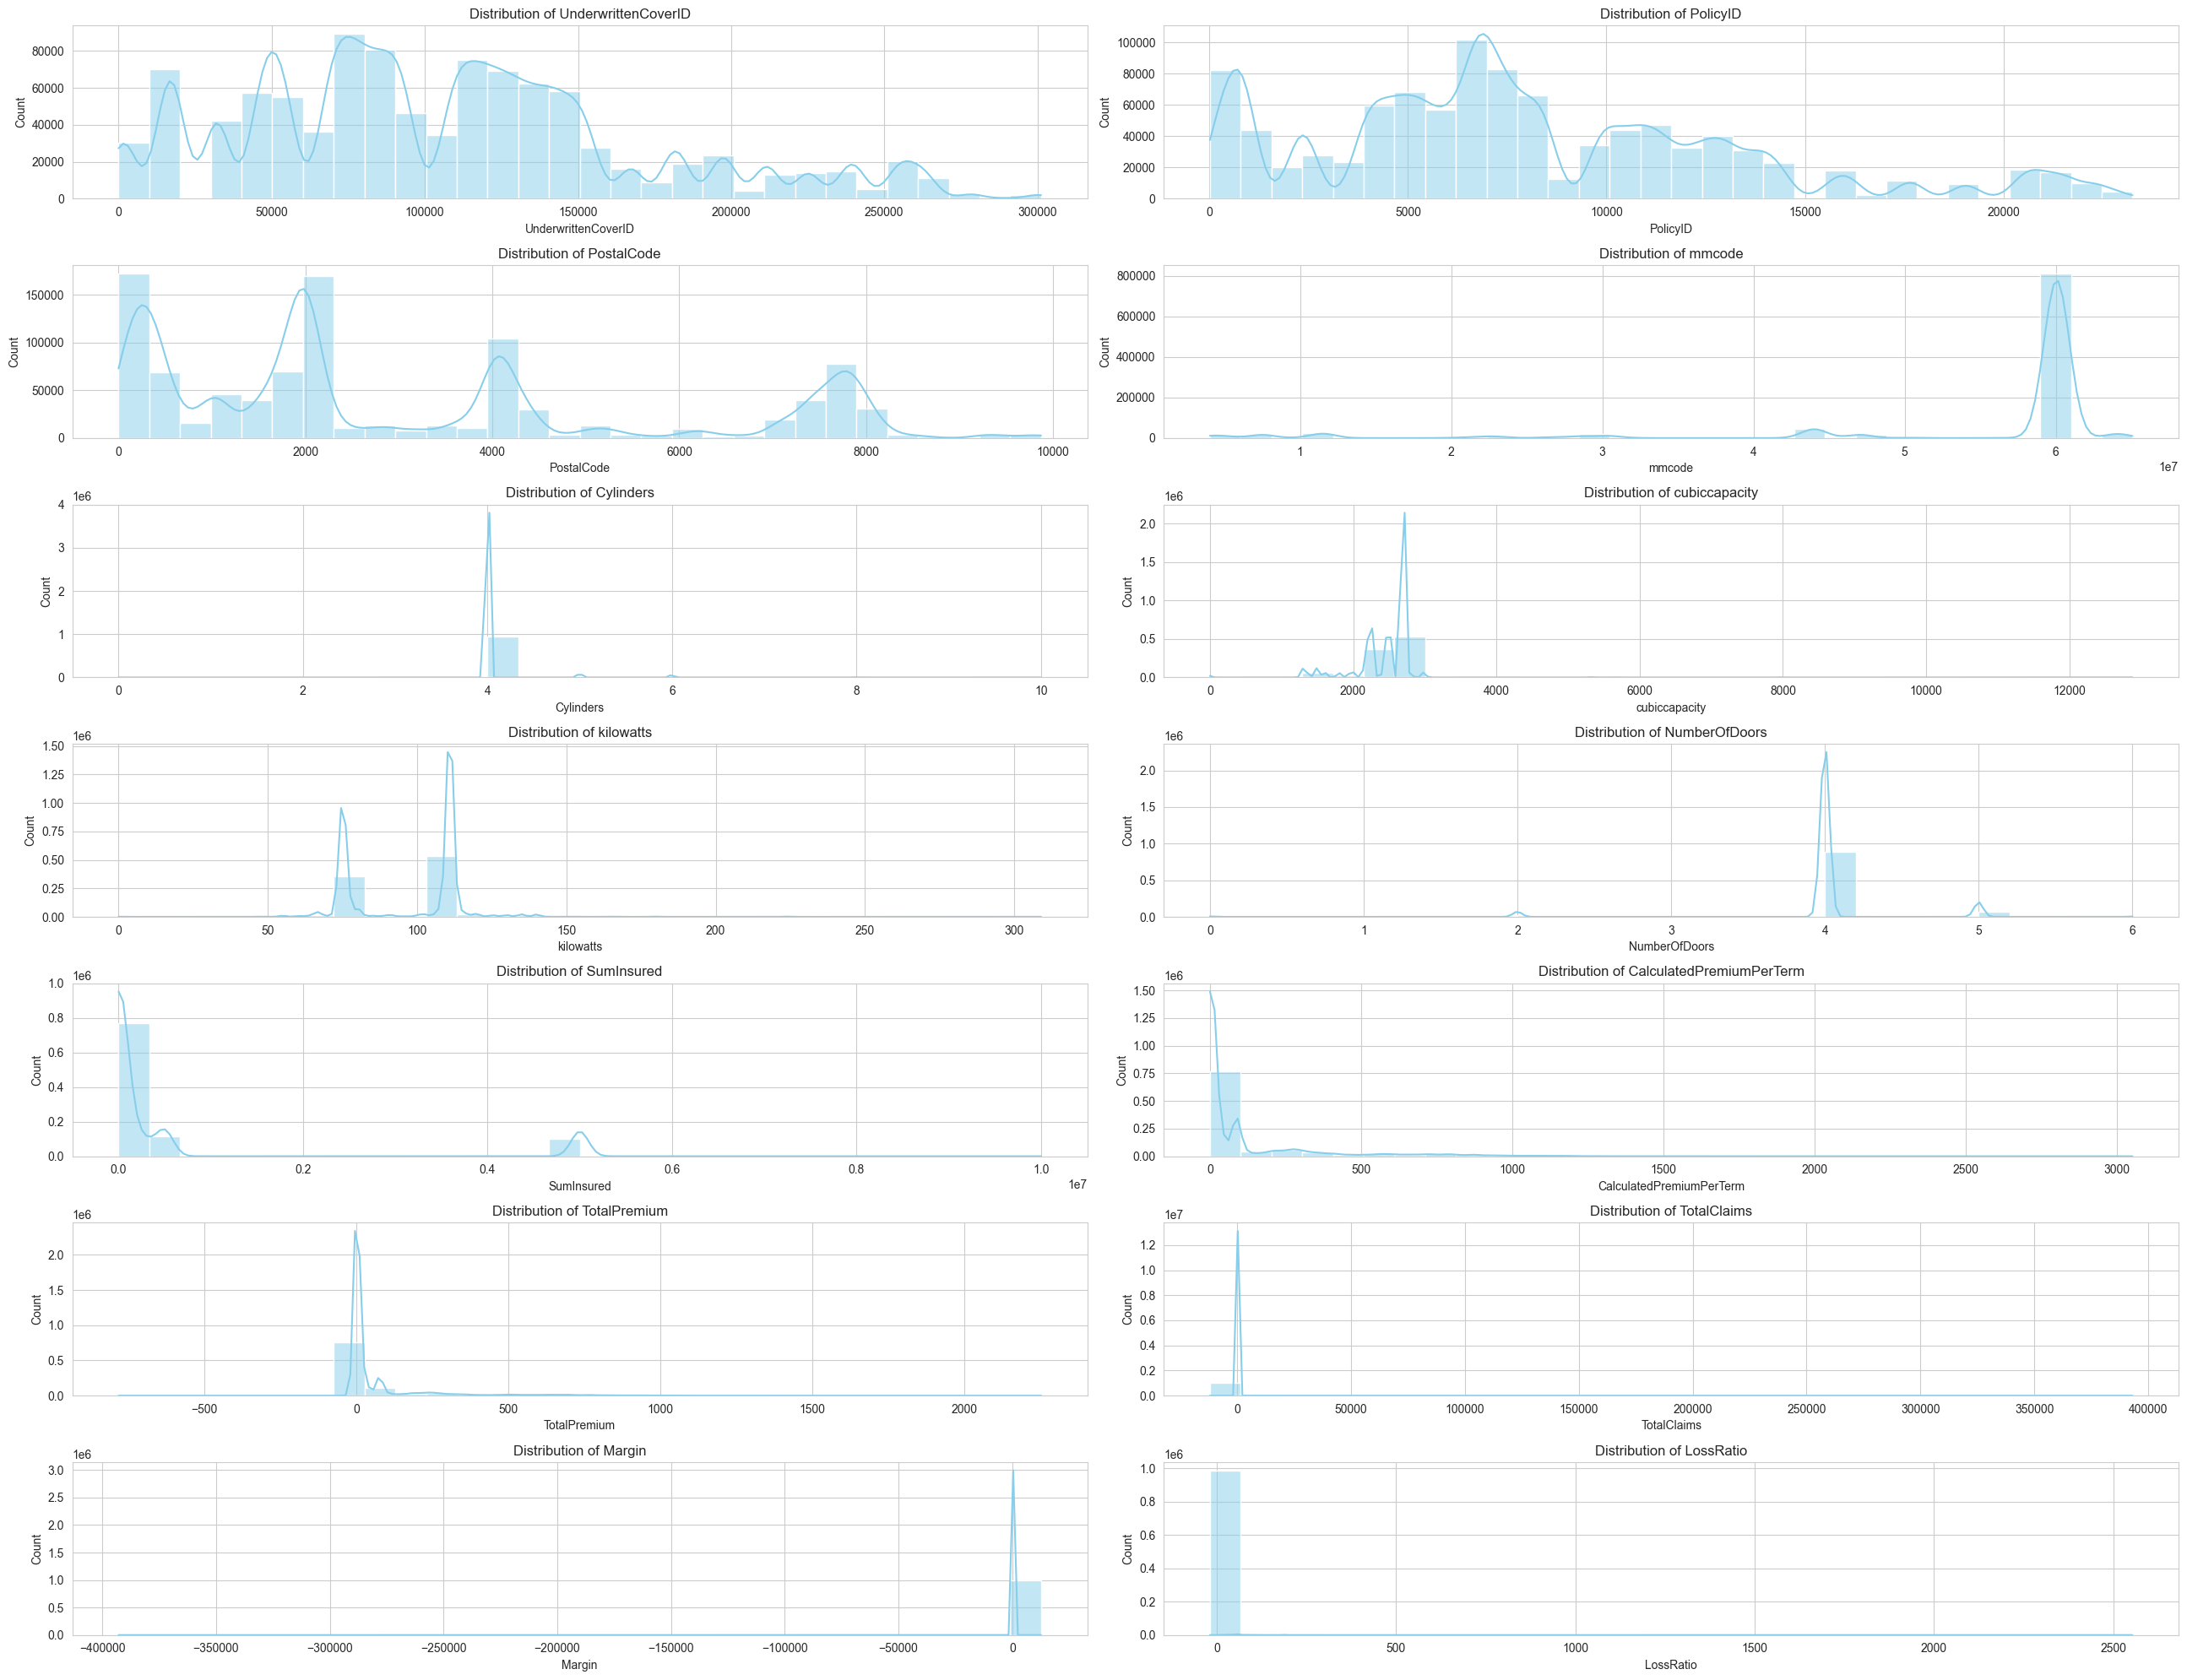

In [19]:
# histograms for numerical columns
numerical_cols = get_numerical_columns(df_clean)
plot_numerical_distributions(df_clean, numerical_cols)

Categorical columns: ['LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'VehicleType', 'make', 'Model', 'bodytype', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'TermFrequency', 'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass', 'StatutoryRiskType']


C:\Users\teMelkishi\Desktop\projects\tenx\projects\insurance-risk-analytics\src\eda_utils.py:506: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cats.values, y=top_cats.index, palette="viridis")
C:\Users\teMelkishi\Desktop\projects\tenx\projects\insurance-risk-analytics\src\eda_utils.py:506: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cats.values, y=top_cats.index, palette="viridis")
C:\Users\teMelkishi\Desktop\projects\tenx\projects\insurance-risk-analytics\src\eda_utils.py:506: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=t

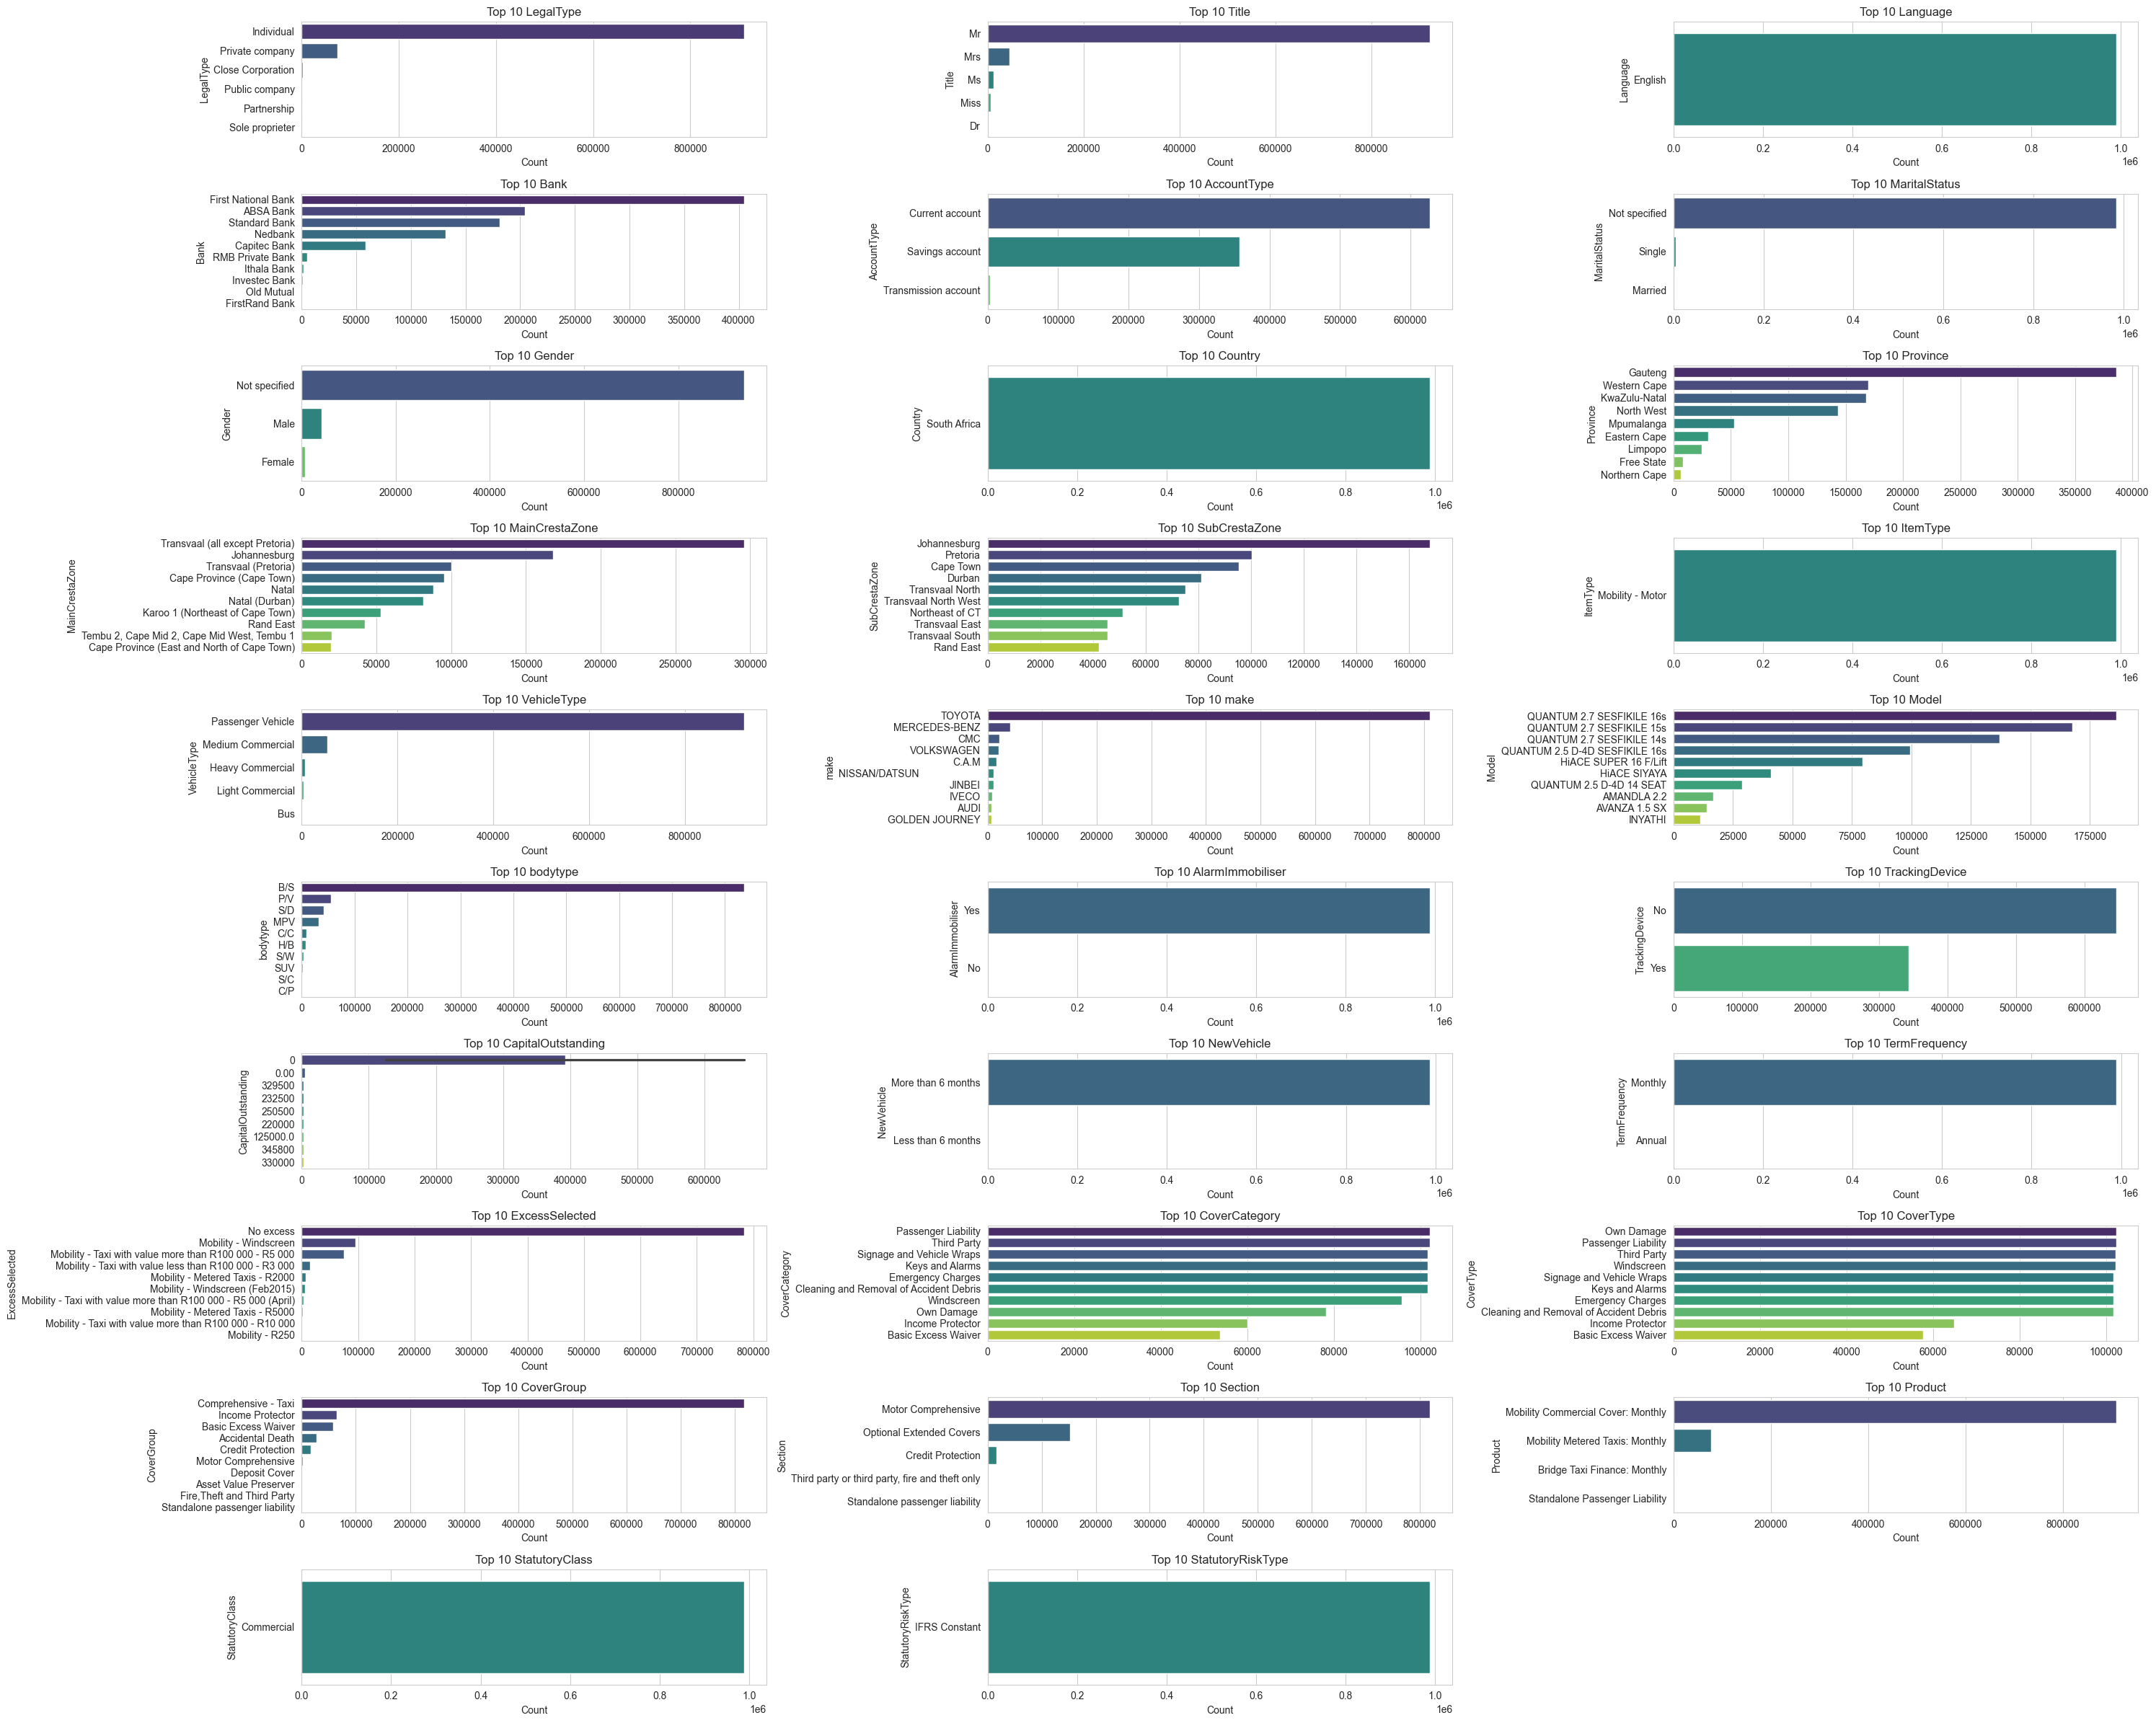

In [20]:
# bar charts for categorical columns
categorical_cols = get_categorical_columns(df_clean)
plot_categorical_distributions(df_clean, categorical_cols)

### Bivariate / Multivariate Analysis

C:\Users\teMelkishi\Desktop\projects\tenx\projects\insurance-risk-analytics\src\eda_utils.py:519: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


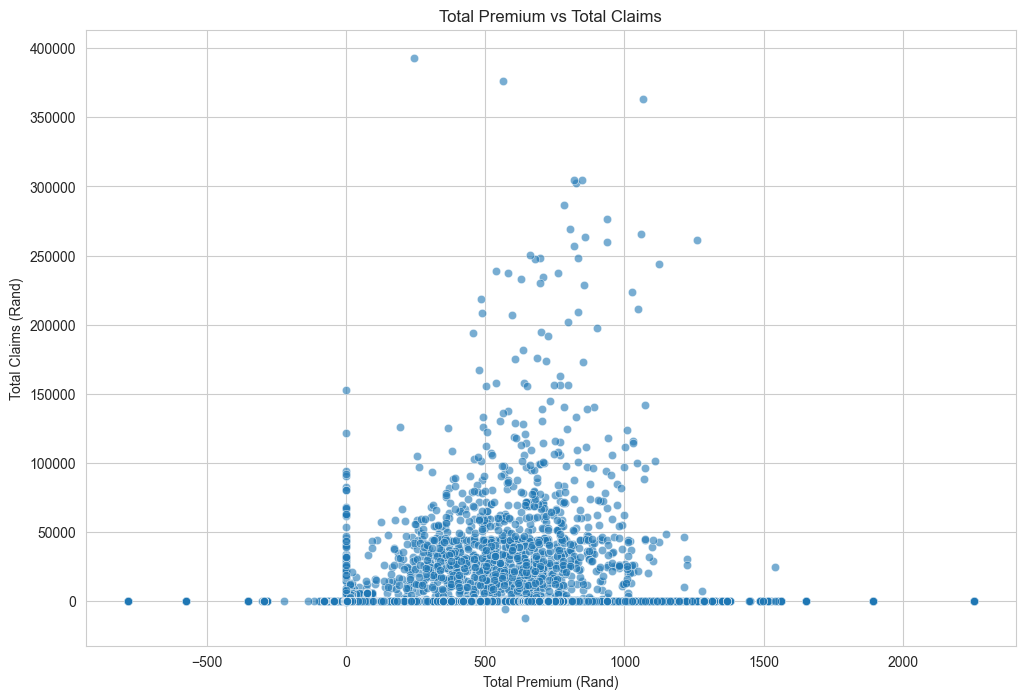

In [21]:
plot_premium_vs_claims(df_clean)

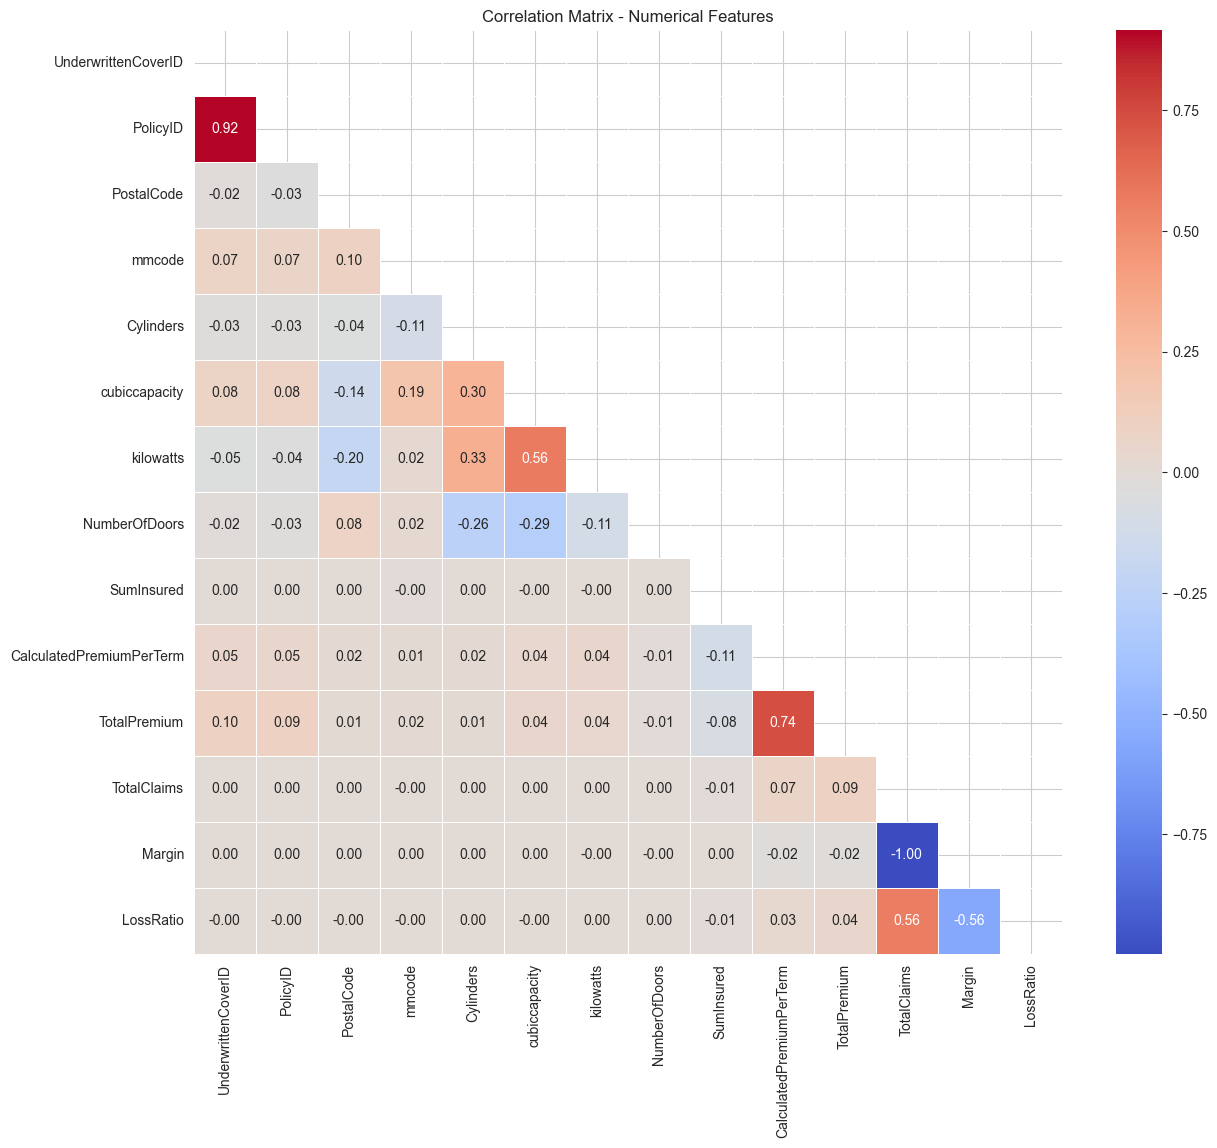

In [22]:
plot_correlation_matrix(df_clean)

### Geographic Trends


=== GEOGRAPHIC TRENDS ===
               TotalPremium   TotalClaims  PolicyID  LossRatio  AvgPremium
Province                                                                  
Gauteng        2.322478e+07  2.888766e+07      2448     124.38     9487.24
KwaZulu-Natal  1.320908e+07  1.430138e+07      1368     108.27     9655.76
Western Cape   9.220794e+06  9.831361e+06       940     106.62     9809.36
North West     7.490508e+06  5.920250e+06      1117      79.04     6705.92
Mpumalanga     2.836106e+06  2.044675e+06       382      72.09     7424.36
Free State     5.213632e+05  3.549223e+05        54      68.08     9654.87
Limpopo        1.537324e+06  1.016477e+06       181      66.12     8493.51
Eastern Cape   2.140104e+06  1.356427e+06       319      63.38     6708.79
Northern Cape  3.165581e+05  8.949051e+04        55      28.27     5755.60


C:\Users\teMelkishi\Desktop\projects\tenx\projects\insurance-risk-analytics\src\eda_utils.py:564: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


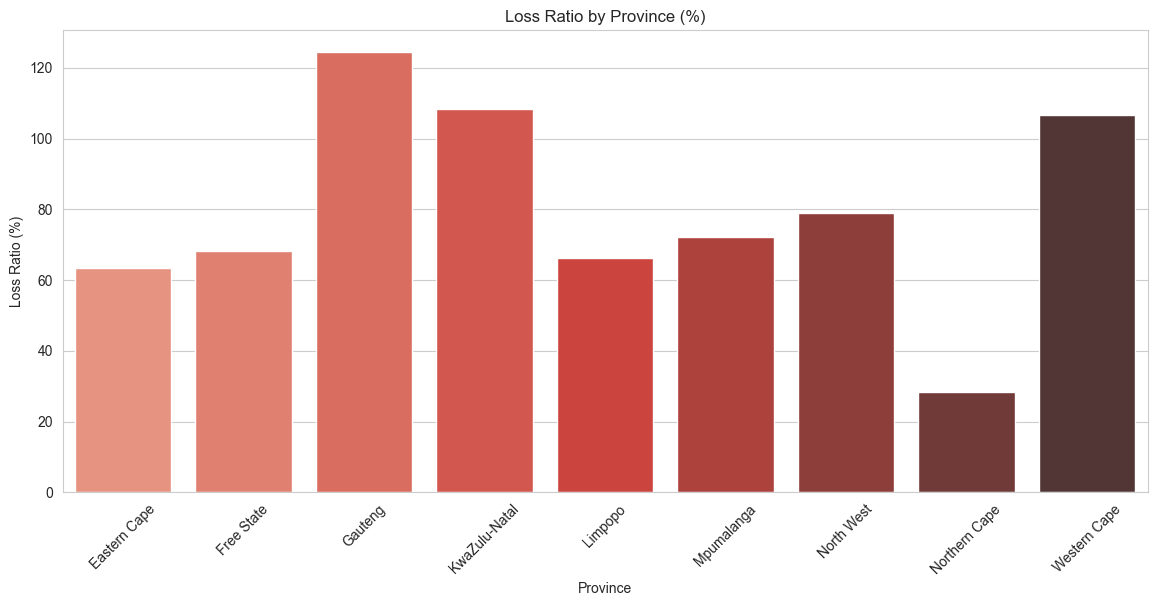

,TotalPremium,TotalClaims,PolicyID,LossRatio,AvgPremium
Province,,,,,
Eastern Cape,2.140104e+06,1.356427e+06,319,63.38,6708.79
Free State,5.213632e+05,3.549223e+05,54,68.08,9654.87
Gauteng,2.322478e+07,2.888766e+07,2448,124.38,9487.24
KwaZulu-Natal,1.320908e+07,1.430138e+07,1368,108.27,9655.76
Limpopo,1.537324e+06,1.016477e+06,181,66.12,8493.51
Mpumalanga,2.836106e+06,2.044675e+06,382,72.09,7424.36
North West,7.490508e+06,5.920250e+06,1117,79.04,6705.92
Northern Cape,3.165581e+05,8.949051e+04,55,28.27,5755.60
Western Cape,9.220794e+06,9.831361e+06,940,106.62,9809.36


In [23]:
analyze_geographic_trends(df_clean)


Top 10 Vehicle Makes by Total Claims:
                 TotalClaims  TotalPremium  LossRatio
make                                                 
TOYOTA          5.174611e+07  4.994554e+07     103.61
MERCEDES-BENZ   2.938695e+06  2.764734e+06     106.29
VOLKSWAGEN      1.839180e+06  1.408843e+06     130.55
CMC             1.323616e+06  9.490992e+05     139.46
AUDI            1.021004e+06  3.762743e+05     271.35
IVECO           7.558930e+05  5.261262e+05     143.67
GOLDEN JOURNEY  7.400894e+05  6.471492e+05     114.36
C.A.M           6.957082e+05  6.074754e+05     114.52
BMW             4.814972e+05  2.427652e+05     198.34
HYUNDAI         4.515807e+05  1.027217e+05     439.62


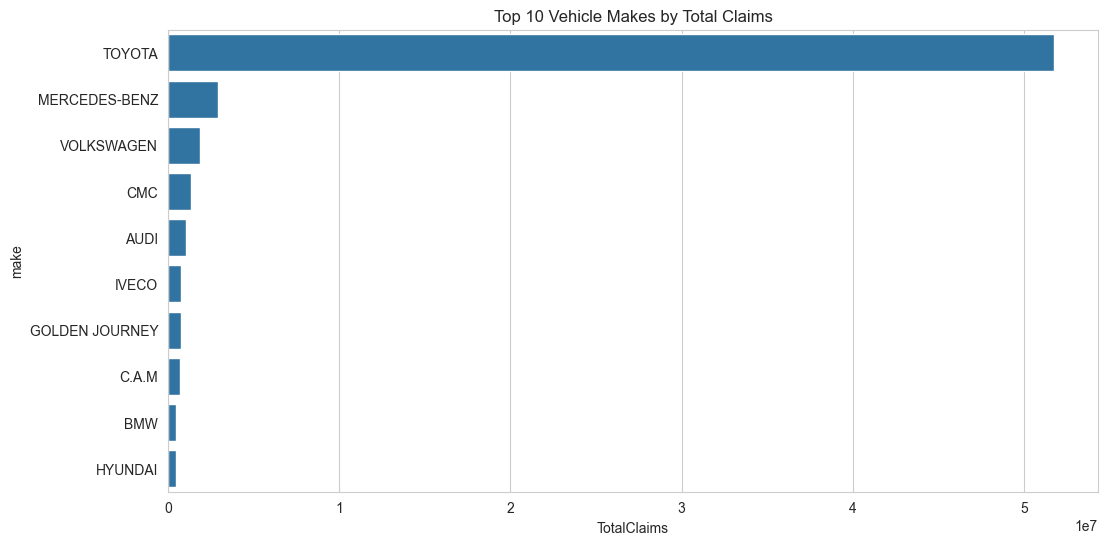

In [24]:
analyze_vehicle_makes(df_clean)

### Outlier Detection

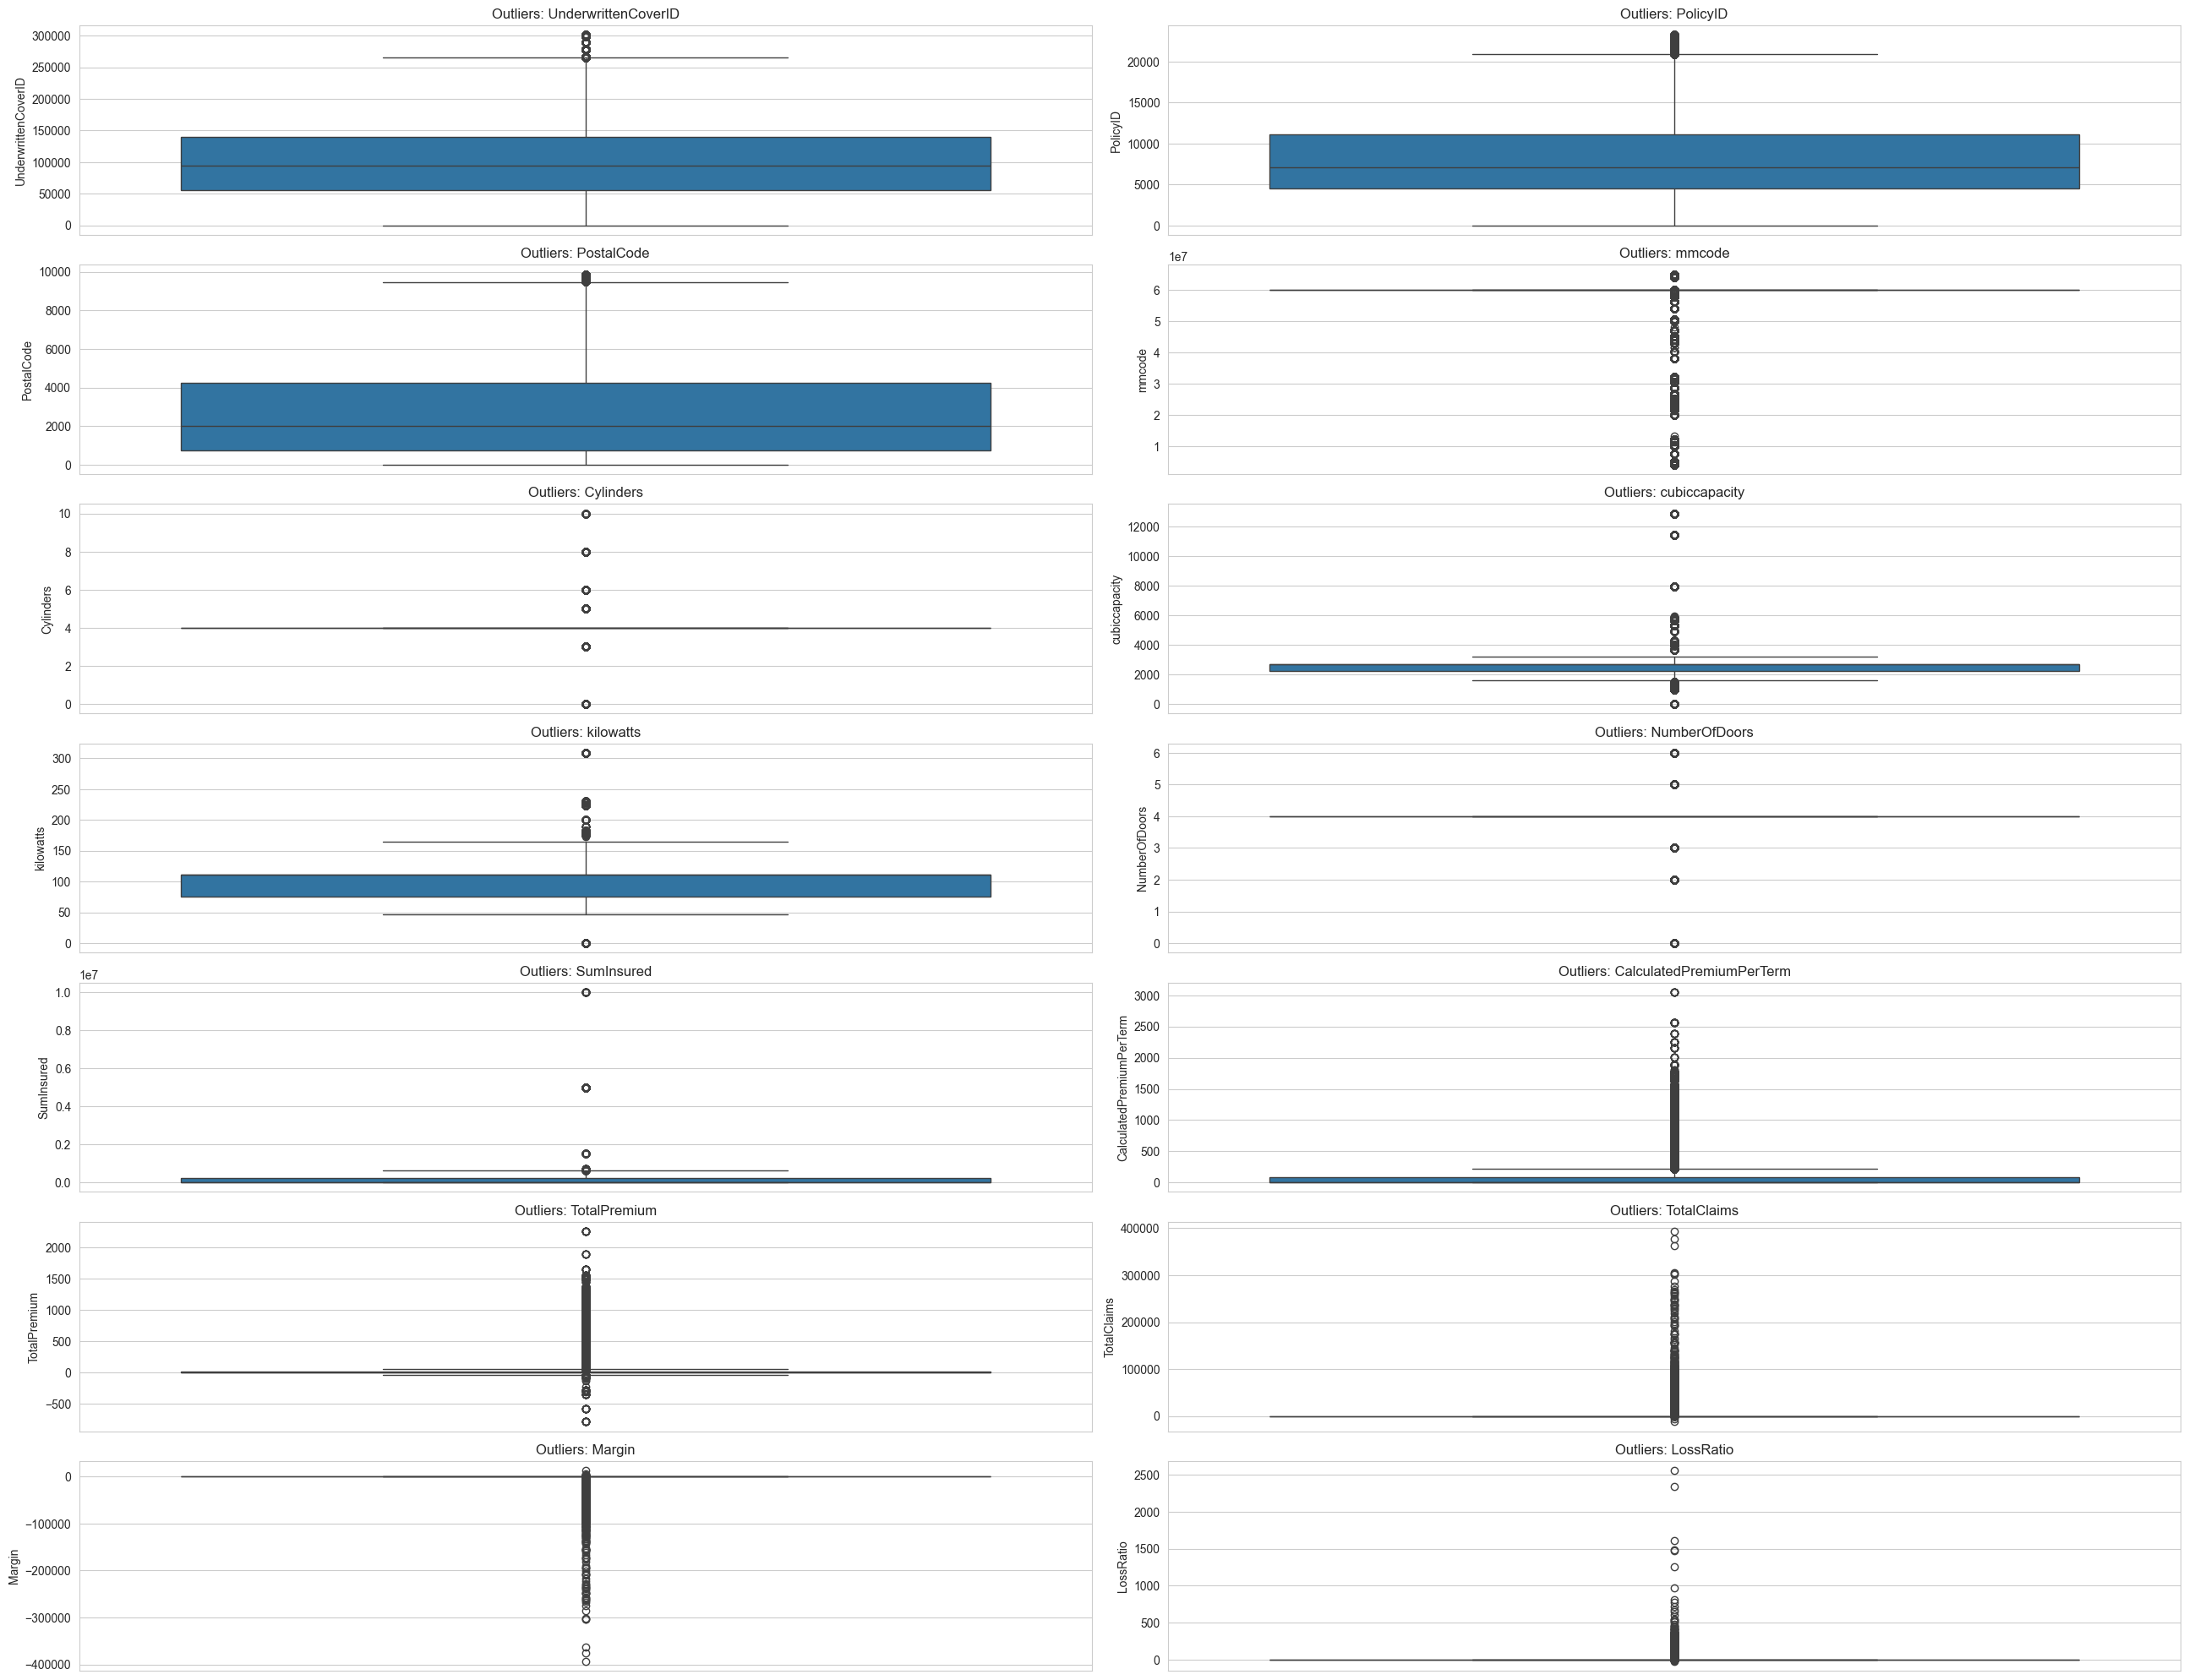


Outlier Summary (IQR Method):
UnderwrittenCoverID      : 5,801 outliers (0.59%)
PolicyID                 : 31,743 outliers (3.21%)
PostalCode               : 4,018 outliers (0.41%)
mmcode                   : 231,525 outliers (23.40%)
Cylinders                : 34,262 outliers (3.46%)
cubiccapacity            : 55,065 outliers (5.57%)
kilowatts                : 2,175 outliers (0.22%)
NumberOfDoors            : 104,688 outliers (10.58%)
SumInsured               : 102,510 outliers (10.36%)
CalculatedPremiumPerTerm : 172,836 outliers (17.47%)
TotalPremium             : 206,582 outliers (20.88%)
TotalClaims              : 2,765 outliers (0.28%)
Margin                   : 207,534 outliers (20.97%)
LossRatio                : 2,615 outliers (0.26%)


In [25]:
detect_outliers(df_clean, numerical_cols)